        date symbol         open         high          low        close  \
0 2021-01-01    BTC  1031.170263  1033.183928  1008.939482  1024.743142   
1 2021-01-02    BTC  2014.384145  2022.364649  2007.869751  2016.479199   
2 2021-01-03    BTC  3052.526017  3052.704227  3038.768842  3051.920512   
3 2021-01-04    BTC  4130.331583  4133.210716  4116.608058  4122.322258   
4 2021-01-05    BTC  5110.116091  5133.608938  5110.845884  5117.347476   

   volume    market_cap  
0    4900  5.021695e+06  
1    3581  7.226180e+06  
2    2428  7.406145e+06  
3    3885  1.603129e+07  
4    4584  2.344602e+07  


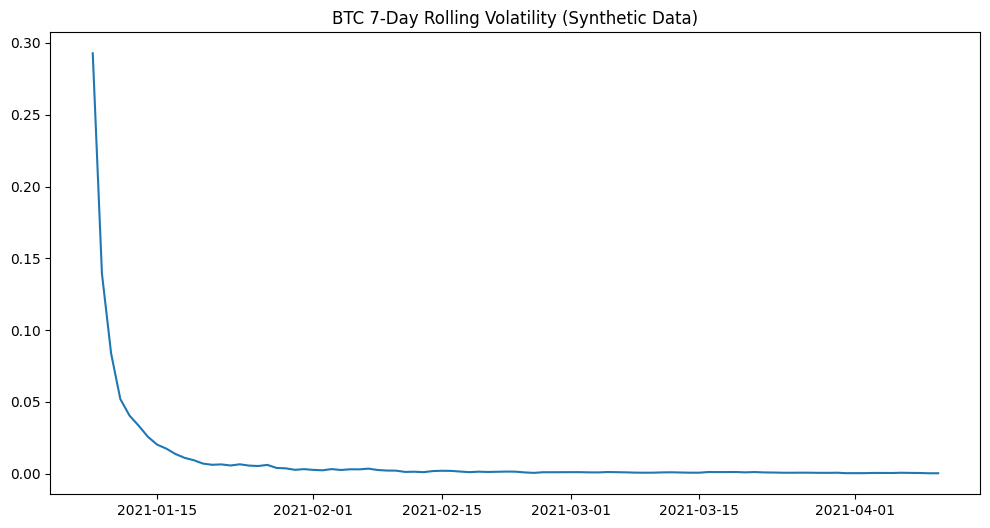

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create a synthetic dataset
# -----------------------------
np.random.seed(42)
dates = pd.date_range(start="2021-01-01", periods=100)
symbols = ["BTC", "ETH"]

data = []
for symbol in symbols:
    price = np.cumsum(np.random.randn(100) * 50 + 1000)  # simulated price
    high = price + np.random.rand(100) * 20
    low = price - np.random.rand(100) * 20
    open_ = price + np.random.randn(100) * 5
    close = price + np.random.randn(100) * 5
    volume = np.random.randint(1000, 5000, size=100)
    market_cap = price * volume
    
    df_symbol = pd.DataFrame({
        "date": dates,
        "symbol": symbol,
        "open": open_,
        "high": high,
        "low": low,
        "close": close,
        "volume": volume,
        "market_cap": market_cap
    })
    data.append(df_symbol)

df = pd.concat(data).reset_index(drop=True)

print(df.head())

# -----------------------------
# 2. Feature Engineering
# -----------------------------
df['returns'] = df.groupby('symbol')['close'].pct_change()
df['volatility'] = df.groupby('symbol')['returns'].rolling(7).std().reset_index(level=0, drop=True)
df['liquidity'] = df['volume'] / df['market_cap']

# -----------------------------
# 3. Scaling
# -----------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['open','high','low','close','volume','market_cap','volatility','liquidity']])

# -----------------------------
# 4. Visualization
# -----------------------------
btc = df[df['symbol']=="BTC"]
plt.figure(figsize=(12,6))
plt.plot(btc['date'], btc['volatility'])
plt.title("BTC 7-Day Rolling Volatility (Synthetic Data)")
plt.show()
